This notebook focuses on implementing a simple convolutional neural network from ground up in numpy.

The implementation will include hyperparameters like 
1. kernels
2. stride
3. pooling
4. padding

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Random experiments to understand the concept of channels and kernels

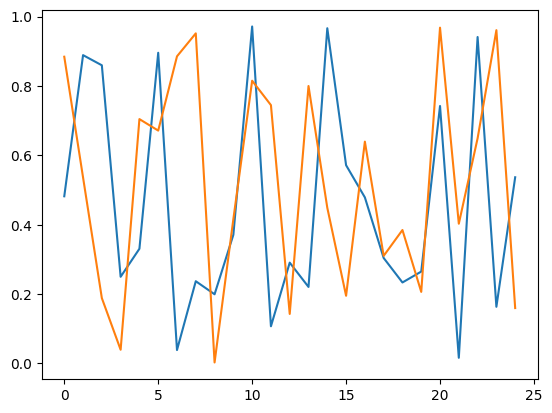

In [2]:
a = np.random.rand(25, 2)

plt.plot(a)

In [3]:
kernel = np.array([[0.25, 0.75]])
print(kernel)

[[0.25 0.75]]


In [4]:
result = [0]*25
for i in range(25):
    for j in [0, 1]:
        result[i] += a[i, j]*kernel[0, j] 

result = np.array(result)
result

array([0.78390904, 0.62451158, 0.35637256, 0.09221103, 0.61119063,
       0.72762407, 0.67391502, 0.77318649, 0.05209965, 0.404933  ,
       0.85440413, 0.58551463, 0.1798475 , 0.65520771, 0.57836838,
       0.2894357 , 0.59946178, 0.30877233, 0.34704954, 0.22106332,
       0.91180527, 0.3063866 , 0.72225449, 0.76166079, 0.25409959])

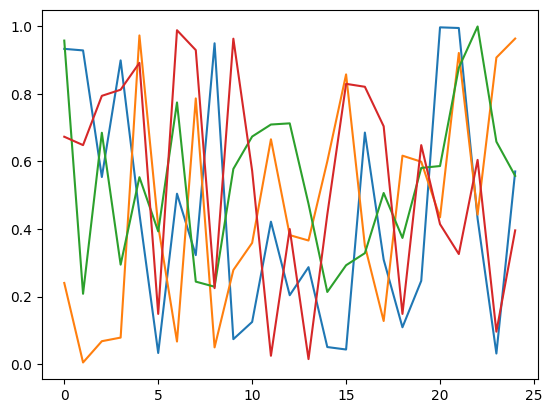

In [5]:
a2 = np.random.rand(25, 4)
plt.plot(a2)

In [6]:
stride = 2
resultdim = (int)(((a2.shape[1] - kernel.shape[1])/ stride) + 1)
result2 = np.zeros((25, resultdim))

for i in range(25):
    for j in range(resultdim):
        sum = 0
        for k in range(kernel.shape[1]):
            sum += a2[i, k + (j*stride)] * kernel[0, k]
        result2[i, j] = sum

result2

array([[0.41359885, 0.74433045],
       [0.23596014, 0.53838978],
       [0.1895205 , 0.7669059 ],
       [0.28381096, 0.68291242],
       [0.84107597, 0.80727997],
       [0.31494931, 0.20983273],
       [0.17642417, 0.93499369],
       [0.67067839, 0.75829763],
       [0.27478339, 0.22612299],
       [0.22752107, 0.86702182],
       [0.30049391, 0.5977258 ],
       [0.60470088, 0.19602737],
       [0.33750379, 0.47817563],
       [0.346337  , 0.12998663],
       [0.46289658, 0.38564842],
       [0.65410377, 0.69551104],
       [0.4342938 , 0.69795825],
       [0.17320747, 0.65479855],
       [0.49016216, 0.20498317],
       [0.51107068, 0.63155368],
       [0.57507215, 0.45744317],
       [0.93962794, 0.46381391],
       [0.43964335, 0.70339144],
       [0.68852791, 0.23681923],
       [0.86543744, 0.43635744]])

In [7]:
# for 2d kernel
kernel2d = np.array([[0.25, 0.25], [0.25, 0.25]])
print(kernel2d.shape)

(2, 2)


In [8]:
dim = (int)(((a2.shape[1] - kernel2d.shape[1])/ stride) + 1)

In [9]:
input = np.random.rand(5, 3)

input_x, input_y = input.shape

kernel = np.array([[0.5, 0.5]])

kernel_x, kernel_y = kernel.shape

stride = 2

output_x, output_y = input_x, int(np.ceil(((input_y - kernel_y)/stride + 1)))

output = np.zeros((output_x, output_y))

In [10]:
input_patches = []

for r in range(input_x):
    patch = []
    for k in range(kernel_y):
        patch.append(input[r, k:k+2])
    input_patches.append(patch)

input_patches = np.array(input_patches)
input_patches.shape

(5, 2, 2)

In [11]:
input_patches

array([[[4.82331011e-01, 7.39057802e-01],
        [7.39057802e-01, 6.64033996e-01]],

       [[3.67844392e-01, 2.01296095e-01],
        [2.01296095e-01, 4.50671278e-01]],

       [[8.43091189e-01, 7.97863295e-01],
        [7.97863295e-01, 7.37893381e-01]],

       [[7.90020641e-01, 1.79660253e-01],
        [1.79660253e-01, 5.59775777e-02]],

       [[6.90992450e-04, 1.79579539e-01],
        [1.79579539e-01, 4.54883381e-01]]])

In [12]:
np.sum(input_patches[1, 0] * kernel)

np.float64(0.2845702430887604)

In [13]:
for r in range(output_x):
    for k in range(output_y):
        output[r, k] = np.sum(input_patches[r, k] * kernel)

In [14]:
output

array([[0.61069441, 0.7015459 ],
       [0.28457024, 0.32598369],
       [0.82047724, 0.76787834],
       [0.48484045, 0.11781892],
       [0.09013527, 0.31723146]])

# Intuitively coding for 2-d images with RGB channels

So, its a numpy implementation of conv2d

In [15]:
kernel3d = np.random.rand(2, 3, 3, 3)
input3d = np.random.rand(3, 4, 5) 

stride = 2
oc, kc, kx, ky = kernel3d.shape
ic, ix, iy = input3d.shape

ox, oy = (ix - kx)//stride + 1, (iy - ky)//stride + 1

output3d = np.zeros((oc, ox, oy))

for c in range(oc): # for each output channel
    for i in range(ox): 
        for j in range(oy): # for each spatial coordinate in output
            kernel = kernel3d[c]
            patch = input3d[:, i*stride:i*stride+kx, j*stride:j*stride+ky]
            if kernel.shape == patch.shape:
                output3d[c, i, j] = np.sum(kernel * patch)

In [16]:
output3d

array([[[4.86495742, 5.88747752]],

       [[4.52301872, 6.12434826]]])

In [50]:
# forward propagation
kernel3d = np.random.rand(2, 3, 3, 3)
input3d = np.random.rand(3, 4, 5) 

stride = 2
oc, kc, kx, ky = kernel3d.shape
ic, ix, iy = input3d.shape

ox, oy = (ix - kx)//stride + 1, (iy - ky)//stride + 1

output3d = np.zeros((oc, ox, oy))

for c in range(oc): # for each output channel
    for i in range(ox): 
        for j in range(oy): # for each spatial coordinate in output
            kernel = kernel3d[c]
            patch = input3d[:, i*stride:i*stride+kx, j*stride:j*stride+ky]
            if kernel.shape == patch.shape:
                output3d[c, i, j] = np.sum(kernel * patch)

# trying to understand how the back prop work
# Lets assume that the output3d is average pooled and then a FC layer is used at the end


avgPool = np.average(output3d, 2) 

flatten_avgPool = avgPool.flatten().reshape(-1, 1)

fapX, fapY = flatten_avgPool.shape


fcW, fcb = np.random.rand(fapX, fapY), np.random.rand(1)

y_fc = flatten_avgPool.T.dot(fcW) + fcb

y_actual = 7 # assuming


# Back propagation starts here 

error = y_fc - y_actual

# derivative of Loss w.r.t weights of fully connected layer fcW, fcb
dLoss_dfcW = error * flatten_avgPool

dLoss_dfcb = error 

# derivative of Loss w.r.t weights of kernel in convolution 
# dLoss_dkernel3d = dLoss_dy_fc * dy_fc_dfavg * dfavg_dOconv * dOconv_dkernel3d

dLoss_dfavg = error * fcW

dLoss_dfavg = dLoss_dfavg.reshape(avgPool.shape)

dLoss_dOconv = (
    dLoss_dfavg[:, :, np.newaxis]
    * np.ones((1, 1, oy))
)

dLoss_dOconv /= output3d.shape[-1]

dLoss_dkernel3d = np.zeros_like(kernel3d)
for c in range(oc): # for each output channel
    for i in range(ox): 
        for j in range(oy): # for each spatial coordinate in output
            kernel = kernel3d[c]
            patch = input3d[:, i*stride:i*stride+kx, j*stride:j*stride+ky]
            if kernel.shape == patch.shape:
                dLoss_dkernel3d[c] +=(dLoss_dOconv[c, i, j] * patch)

print("Original")
print(kernel3d)
print(fcW)
print(fcb)

kernel3d -= dLoss_dkernel3d
fcW -= dLoss_dfcW
fcb -= dLoss_dfcb.flatten()

print("Updated")
print(kernel3d)
print(fcW)
print(fcb)


Original
[[[[0.24303817 0.06399347 0.71987107]
   [0.49054061 0.03900763 0.2760221 ]
   [0.93441897 0.50759525 0.45631658]]

  [[0.33826271 0.7622625  0.03098252]
   [0.25086268 0.66552399 0.8478665 ]
   [0.14144423 0.44487746 0.49012381]]

  [[0.93884861 0.95787482 0.88368288]
   [0.70138772 0.89239916 0.55216569]
   [0.67378404 0.87666552 0.74261895]]]


 [[[0.8064014  0.86058002 0.75702846]
   [0.77292623 0.14774274 0.79887266]
   [0.36664409 0.03615983 0.2407727 ]]

  [[0.01784121 0.71507014 0.95467821]
   [0.98007116 0.7793905  0.18479368]
   [0.32450603 0.60303068 0.18352576]]

  [[0.94002767 0.0999032  0.50686694]
   [0.04276169 0.09830854 0.8700549 ]
   [0.80691589 0.18796028 0.22713205]]]]
[[0.01952262]
 [0.67375021]]
[0.99463126]
Updated
[[[[0.2499978  0.07676836 0.73758282]
   [0.51659516 0.05412675 0.29561857]
   [0.96814471 0.52488807 0.48317327]]

  [[0.34626662 0.78924685 0.04560071]
   [0.27623231 0.67211726 0.86777467]
   [0.15563017 0.46170788 0.50261959]]

  [[0.9484